[PPD] Group Project: Deteksi Dini Risiko Diabetes Melitus Tipe 2 Berdasarkan Gejala Klinis Awal Menggunakan Machine Learning

Mata Kuliah: Praktikum Penambangan Data (Gasal 2026/2027)
Kelas:PL5A1
Kelompok 3:
1. Lilis Puspita Haria
2. Aurell Achmad Madina Hartama
3. Hafidz Rizqullah Prasetya
4. Muhammad Zidan Alhilali

Dosen Pengampu:
- Dr.Eng. Ir. Ganjar Alfian, S.T., M.Eng
- Dr. Imam Fahrurrozi, S.T., M.Cs.

Dataset: UCI Early Stage Diabetes Risk Prediction Dataset (520 Pasien)
Paper Acuan:Symptoms affecting the development of diabetes: analysis of risk factors with data mining (BMC Medical Informatics and Decision
Making, Springer Nature, 2025)
                                

1. Data Cleansing & Preprocessing

In [6]:
# Import library

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Library berhasil diimport.")

Library berhasil diimport.


In [7]:
from google.colab import files
import pandas as pd

# Dont forget download the dataset from this page: https://archive.ics.uci.edu/dataset/529/early+stage+diabetes+risk+prediction+dataset

# Just changing how we upload the dataset, with this method, it is more practical and flexible, rather than the mount and specified fixed drive directory method

uploaded = files.upload()

filename = next(iter(uploaded))
df = pd.read_csv(filename)

print("Dataset berhasil dimuat!")
print("Ukuran dataset:", df.shape)

display(df.head())

Saving diabetes_data_upload.csv to diabetes_data_upload (1).csv
Dataset berhasil dimuat!
Ukuran dataset: (520, 17)


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,Male,No,Yes,No,Yes,No,No,No,Yes,No,Yes,No,Yes,Yes,Yes,Positive
1,58,Male,No,No,No,Yes,No,No,Yes,No,No,No,Yes,No,Yes,No,Positive
2,41,Male,Yes,No,No,Yes,Yes,No,No,Yes,No,Yes,No,Yes,Yes,No,Positive
3,45,Male,No,No,Yes,Yes,Yes,Yes,No,Yes,No,Yes,No,No,No,No,Positive
4,60,Male,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Positive


In [8]:
# pemeriksaan dataset
print("=== INFORMASI DATASET ===")
df.info()

=== INFORMASI DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 520 entries, 0 to 519
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Age                 520 non-null    int64 
 1   Gender              520 non-null    object
 2   Polyuria            520 non-null    object
 3   Polydipsia          520 non-null    object
 4   sudden weight loss  520 non-null    object
 5   weakness            520 non-null    object
 6   Polyphagia          520 non-null    object
 7   Genital thrush      520 non-null    object
 8   visual blurring     520 non-null    object
 9   Itching             520 non-null    object
 10  Irritability        520 non-null    object
 11  delayed healing     520 non-null    object
 12  partial paresis     520 non-null    object
 13  muscle stiffness    520 non-null    object
 14  Alopecia            520 non-null    object
 15  Obesity             520 non-null    object
 16  

In [9]:
print("=== NAMA KOLOM ===")
print(df.columns.tolist())

=== NAMA KOLOM ===
['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity', 'class']


In [10]:
# check missing value
print("=== MISSING VALUE ===")

missing_values = df.isnull().sum()

display(missing_values)

=== MISSING VALUE ===


,0
Age,0
Gender,0
Polyuria,0
Polydipsia,0
sudden weight loss,0
weakness,0
Polyphagia,0
Genital thrush,0
visual blurring,0
Itching,0


In [11]:
# cek data yg keduplicate
print("=== DATA DUPLIKAT ===")

duplicate_count = df.duplicated().sum()

print("Jumlah data duplikat:", duplicate_count)

=== DATA DUPLIKAT ===
Jumlah data duplikat: 269


In [12]:
# cek nilai unik
print("=== NILAI UNIK SETIAP KOLOM ===")

for column in df.columns:
    print(f"\n{column}:")
    print(df[column].unique())

=== NILAI UNIK SETIAP KOLOM ===

Age:
[40 58 41 45 60 55 57 66 67 70 44 38 35 61 54 43 62 39 48 32 42 52 53 37
 49 63 30 50 46 36 51 59 65 25 47 28 68 56 31 85 90 72 69 79 34 16 33 64
 27 29 26]

Gender:
['Male' 'Female']

Polyuria:
['No' 'Yes']

Polydipsia:
['Yes' 'No']

sudden weight loss:
['No' 'Yes']

weakness:
['Yes' 'No']

Polyphagia:
['No' 'Yes']

Genital thrush:
['No' 'Yes']

visual blurring:
['No' 'Yes']

Itching:
['Yes' 'No']

Irritability:
['No' 'Yes']

delayed healing:
['Yes' 'No']

partial paresis:
['No' 'Yes']

muscle stiffness:
['Yes' 'No']

Alopecia:
['Yes' 'No']

Obesity:
['Yes' 'No']

class:
['Positive' 'Negative']


In [13]:
# hapus duplikat data
# Membuat salinan dataset
data = df.copy()

# Menghapus data duplikat
data = data.drop_duplicates().reset_index(drop=True)

print("=== HASIL DATA CLEANING ===")
print("Jumlah data sebelum cleaning :", len(df))
print("Jumlah data setelah cleaning :", len(data))
print("Jumlah data yang dihapus     :", len(df) - len(data))
print("Jumlah kolom                 :", data.shape[1])

=== HASIL DATA CLEANING ===
Jumlah data sebelum cleaning : 520
Jumlah data setelah cleaning : 251
Jumlah data yang dihapus     : 269
Jumlah kolom                 : 17


In [14]:
# cek missing value
print("=== MISSING VALUE SETELAH CLEANING ===")

missing_values = data.isnull().sum()

display(missing_values)

if missing_values.sum() == 0:
    print("Tidak terdapat missing value.")
else:
    print("Terdapat missing value yang perlu ditangani.")

=== MISSING VALUE SETELAH CLEANING ===


,0
Age,0
Gender,0
Polyuria,0
Polydipsia,0
sudden weight loss,0
weakness,0
Polyphagia,0
Genital thrush,0
visual blurring,0
Itching,0


Tidak terdapat missing value.


In [15]:
# cek duplikasi data setelah cleaning
print("=== PENGECEKAN DUPLIKAT ===")

duplicate_after = data.duplicated().sum()

print("Jumlah duplikat setelah cleaning:", duplicate_after)

=== PENGECEKAN DUPLIKAT ===
Jumlah duplikat setelah cleaning: 0


In [16]:
# Encoding data kategorikal
# Kolom dengan nilai Yes/No
yes_no_columns = [
    'Polyuria',
    'Polydipsia',
    'sudden weight loss',
    'weakness',
    'Polyphagia',
    'Genital thrush',
    'visual blurring',
    'Itching',
    'Irritability',
    'delayed healing',
    'partial paresis',
    'muscle stiffness',
    'Alopecia',
    'Obesity'
]

# Encoding Yes/No menjadi 1/0
for column in yes_no_columns:
    data[column] = data[column].map({
        'Yes': 1,
        'No': 0
    })

# Encoding Gender
data['Gender'] = data['Gender'].map({
    'Male': 1,
    'Female': 0
})

# Encoding target
data['class'] = data['class'].map({
    'Positive': 1,
    'Negative': 0
})

print("Encoding berhasil dilakukan.")
display(data.head())

Encoding berhasil dilakukan.


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity,class
0,40,1,0,1,0,1,0,0,0,1,0,1,0,1,1,1,1
1,58,1,0,0,0,1,0,0,1,0,0,0,1,0,1,0,1
2,41,1,1,0,0,1,1,0,0,1,0,1,0,1,1,0,1
3,45,1,0,0,1,1,1,1,0,1,0,1,0,0,0,0,1
4,60,1,1,1,1,1,1,0,1,1,1,1,1,1,1,1,1


In [17]:
# verif encoding
print("=== TIPE DATA SETELAH ENCODING ===")
display(data.dtypes)

print("\n=== NILAI UNIK SETELAH ENCODING ===")

for column in data.columns:
    print(f"{column}: {data[column].unique()}")

=== TIPE DATA SETELAH ENCODING ===


,0
Age,int64
Gender,int64
Polyuria,int64
Polydipsia,int64
sudden weight loss,int64
weakness,int64
Polyphagia,int64
Genital thrush,int64
visual blurring,int64
Itching,int64



=== NILAI UNIK SETELAH ENCODING ===
Age: [40 58 41 45 60 55 57 66 67 70 44 38 35 61 54 43 62 39 48 32 42 52 53 37
 49 63 30 50 46 36 51 59 65 25 47 28 68 56 31 85 90 72 69 79 34 16 33 64
 27 29 26]
Gender: [1 0]
Polyuria: [0 1]
Polydipsia: [1 0]
sudden weight loss: [0 1]
weakness: [1 0]
Polyphagia: [0 1]
Genital thrush: [0 1]
visual blurring: [0 1]
Itching: [1 0]
Irritability: [0 1]
delayed healing: [1 0]
partial paresis: [0 1]
muscle stiffness: [1 0]
Alopecia: [1 0]
Obesity: [1 0]
class: [1 0]


In [18]:
# Memisahkan feature dan target
X = data.drop(columns=['class'])
y = data['class']

print("=== PEMISAHAN FEATURE DAN TARGET ===")
print("Jumlah data    :", len(data))
print("Jumlah feature :", X.shape[1])
print("Nama target    :", y.name)

print("\nFeature:")
print(X.columns.tolist())

=== PEMISAHAN FEATURE DAN TARGET ===
Jumlah data    : 251
Jumlah feature : 16
Nama target    : class

Feature:
['Age', 'Gender', 'Polyuria', 'Polydipsia', 'sudden weight loss', 'weakness', 'Polyphagia', 'Genital thrush', 'visual blurring', 'Itching', 'Irritability', 'delayed healing', 'partial paresis', 'muscle stiffness', 'Alopecia', 'Obesity']


In [19]:
# Train-Test Split dengan Stratified Sampling
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("=== HASIL TRAIN-TEST SPLIT ===")
print("X_train :", X_train.shape)
print("X_test  :", X_test.shape)
print("y_train :", y_train.shape)
print("y_test  :", y_test.shape)

=== HASIL TRAIN-TEST SPLIT ===
X_train : (175, 16)
X_test  : (76, 16)
y_train : (175,)
y_test  : (76,)


In [20]:
# Verifikasi Stratified Sampling
print("=== PROPORSI TARGET ===")

print("Data keseluruhan:")
display(y.value_counts(normalize=True).rename("Proporsi"))

print("\nData training:")
display(y_train.value_counts(normalize=True).rename("Proporsi"))

print("\nData testing:")
display(y_test.value_counts(normalize=True).rename("Proporsi"))

=== PROPORSI TARGET ===
Data keseluruhan:


,Proporsi
class,
1,0.689243
0,0.310757



Data training:


,Proporsi
class,
1,0.691429
0,0.308571



Data testing:


,Proporsi
class,
1,0.684211
0,0.315789


In [21]:
# Feature Scaling
# Standardisasi fitur
scaler = StandardScaler()

# Fit hanya pada data training
X_train_scaled = scaler.fit_transform(X_train)

# Transform data testing menggunakan scaler dari training
X_test_scaled = scaler.transform(X_test)

# Mengubah kembali menjadi DataFrame
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

print("=== HASIL FEATURE SCALING ===")
print("X_train_scaled:", X_train_scaled.shape)
print("X_test_scaled :", X_test_scaled.shape)

display(X_train_scaled.head())

=== HASIL FEATURE SCALING ===
X_train_scaled: (175, 16)
X_test_scaled : (76, 16)


,Age,Gender,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
217,-1.669565,-1.300887,-1.089725,-1.028992,-0.826252,-1.333333,1.017292,-0.605960,-0.939,-0.939,-0.659110,-0.983002,1.102357,-0.826252,-0.75,-0.491055
223,-1.036469,0.768706,-1.089725,-1.028992,-0.826252,-1.333333,-0.983002,-0.605960,-0.939,-0.939,-0.659110,-0.983002,-0.907148,-0.826252,-0.75,-0.491055
170,-1.194743,0.768706,-1.089725,-1.028992,-0.826252,-1.333333,-0.983002,-0.605960,-0.939,-0.939,-0.659110,-0.983002,-0.907148,-0.826252,-0.75,-0.491055
201,-1.827840,0.768706,-1.089725,-1.028992,-0.826252,-1.333333,-0.983002,-0.605960,-0.939,-0.939,-0.659110,-0.983002,-0.907148,-0.826252,-0.75,-0.491055
155,0.467135,0.768706,0.917663,0.971825,1.210285,0.750000,-0.983002,1.650274,-0.939,-0.939,1.517197,-0.983002,1.102357,-0.826252,-0.75,-0.491055


In [22]:
# Final Check
print("============================================")
print("       PREPROCESSING SELESAI")
print("============================================")

print("\nX_train_scaled :", X_train_scaled.shape)
print("X_test_scaled  :", X_test_scaled.shape)
print("y_train        :", y_train.shape)
print("y_test         :", y_test.shape)

print("\nDistribusi target training:")
print(y_train.value_counts())

print("\nDistribusi target testing:")
print(y_test.value_counts())

       PREPROCESSING SELESAI

X_train_scaled : (175, 16)
X_test_scaled  : (76, 16)
y_train        : (175,)
y_test         : (76,)

Distribusi target training:
class
1    121
0     54
Name: count, dtype: int64

Distribusi target testing:
class
1    52
0    24
Name: count, dtype: int64


**Catatan Hasil Preprocessing**

Setelah dilakukan cleaning dan preprocessing, data yang digunakan berjumlah 251 data dengan 16 fitur. Data kategorikal seperti `Yes/No`, `Gender`, dan `class` sudah diubah menjadi bentuk numerik. Selanjutnya, data dibagi menjadi data training dan testing dengan perbandingan 70:30 menggunakan stratified sampling. Hasilnya diperoleh 175 data training dan 76 data testing. Setelah itu, fitur dilakukan scaling menggunakan StandardScaler sehingga data siap digunakan untuk proses pemodelan.


**EXPLORATORY DATA ANALYSIS (EDA) & VISUALISASI**

Deteksi Dini Risiko Diabetes Melitus Tipe 2

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option('display.max_columns', None)

print("=" * 70)
print("       EDA & VISUALISASI DATA")
print("=" * 70)


print("=" * 70)
print("1. KARAKTERISTIK DATA")
print("=" * 70)

print(f"Jumlah data setelah preprocessing : {data.shape[0]}")
print(f"Jumlah kolom                     : {data.shape[1]}")
print(f"Jumlah fitur                     : {X.shape[1]}")
print(f"Jumlah target                    : 1")
print(f"Nama target                      : {y.name}")

print("\nDaftar fitur:")
for i, column in enumerate(X.columns, start=1):
    print(f"{i:2}. {column}")



       EDA & VISUALISASI DATA
1. KARAKTERISTIK DATA
Jumlah data setelah preprocessing : 251
Jumlah kolom                     : 17
Jumlah fitur                     : 16
Jumlah target                    : 1
Nama target                      : class

Daftar fitur:
 1. Age
 2. Gender
 3. Polyuria
 4. Polydipsia
 5. sudden weight loss
 6. weakness
 7. Polyphagia
 8. Genital thrush
 9. visual blurring
10. Itching
11. Irritability
12. delayed healing
13. partial paresis
14. muscle stiffness
15. Alopecia
16. Obesity


In [24]:
print("\n" + "=" * 70)
print("2. STATISTIK DESKRIPTIF")
print("=" * 70)

print("\nStatistik deskriptif fitur Age:")

display(
    data[['Age']].describe().round(2)
)


# Statistik usia secara lebih mudah dibaca
print("\nRingkasan usia:")
print(f"Rata-rata : {data['Age'].mean():.2f} tahun")
print(f"Median    : {data['Age'].median():.2f} tahun")
print(f"Std. Dev  : {data['Age'].std():.2f} tahun")
print(f"Minimum   : {data['Age'].min()} tahun")
print(f"Maksimum  : {data['Age'].max()} tahun")


2. STATISTIK DESKRIPTIF

Statistik deskriptif fitur Age:


,Age
count,251.00
mean,48.86
std,12.53
min,16.00
25%,39.00
50%,48.00
75%,58.00
max,90.00



Ringkasan usia:
Rata-rata : 48.86 tahun
Median    : 48.00 tahun
Std. Dev  : 12.53 tahun
Minimum   : 16 tahun
Maksimum  : 90 tahun



3. DISTRIBUSI USIA


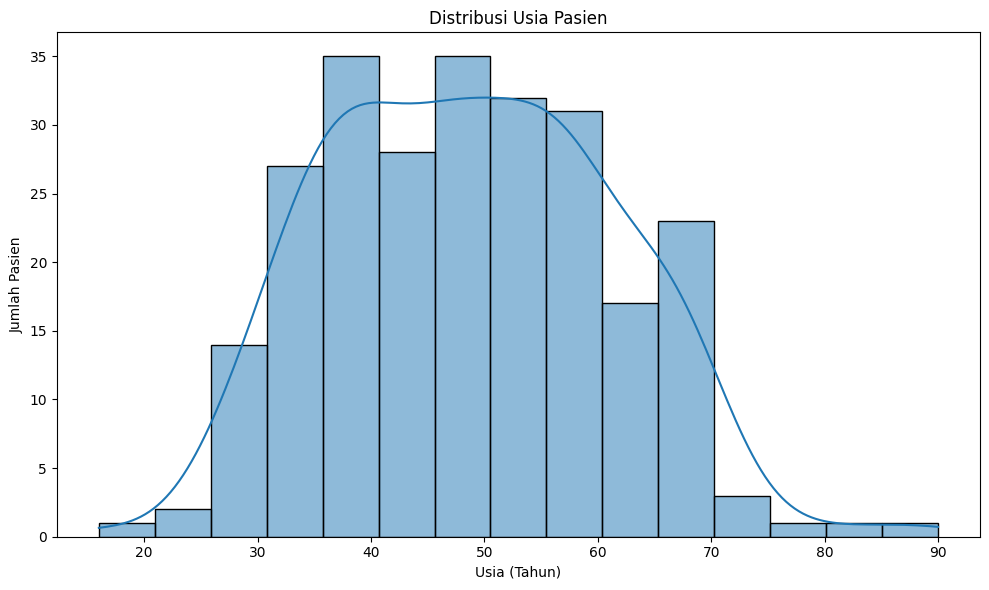

In [25]:
print("\n" + "=" * 70)
print("3. DISTRIBUSI USIA")
print("=" * 70)

plt.figure(figsize=(10, 6))

sns.histplot(
    data=data,
    x='Age',
    bins=15,
    kde=True
)

plt.title('Distribusi Usia Pasien')
plt.xlabel('Usia (Tahun)')
plt.ylabel('Jumlah Pasien')

plt.tight_layout()
plt.show()


4. DISTRIBUSI GENDER
Jumlah pasien berdasarkan gender:


,count
Gender,
Male,160
Female,91



Persentase pasien berdasarkan gender:


,proportion
Gender,
Male,63.75
Female,36.25


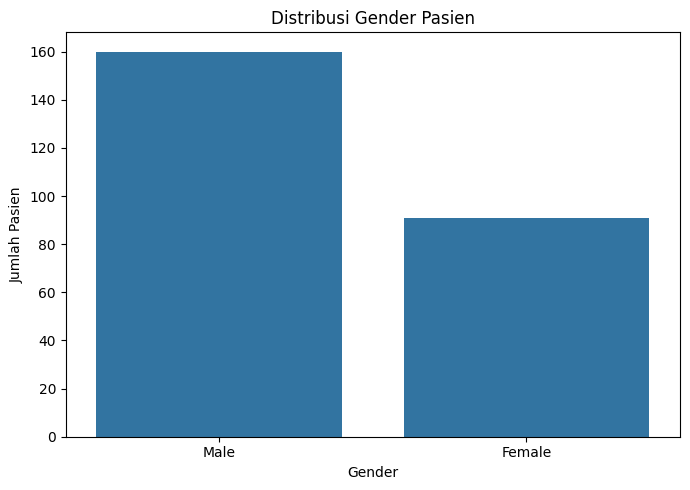

In [26]:
print("\n" + "=" * 70)
print("4. DISTRIBUSI GENDER")
print("=" * 70)

# Gender sudah di-encode oleh preprocessing:
# Male   = 1
# Female = 0

gender_label = data['Gender'].map({
    1: 'Male',
    0: 'Female'
})

gender_counts = gender_label.value_counts()

gender_percentage = (
    gender_label.value_counts(normalize=True) * 100
)

print("Jumlah pasien berdasarkan gender:")
display(gender_counts)

print("\nPersentase pasien berdasarkan gender:")
display(gender_percentage.round(2))


plt.figure(figsize=(7, 5))

sns.countplot(
    x=gender_label,
    order=['Male', 'Female']
)

plt.title('Distribusi Gender Pasien')
plt.xlabel('Gender')
plt.ylabel('Jumlah Pasien')

plt.tight_layout()
plt.show()


5. DISTRIBUSI CLASS
Jumlah pasien berdasarkan class:


,count
class,
Positive,173
Negative,78



Persentase pasien berdasarkan class:


,proportion
class,
Positive,68.92
Negative,31.08


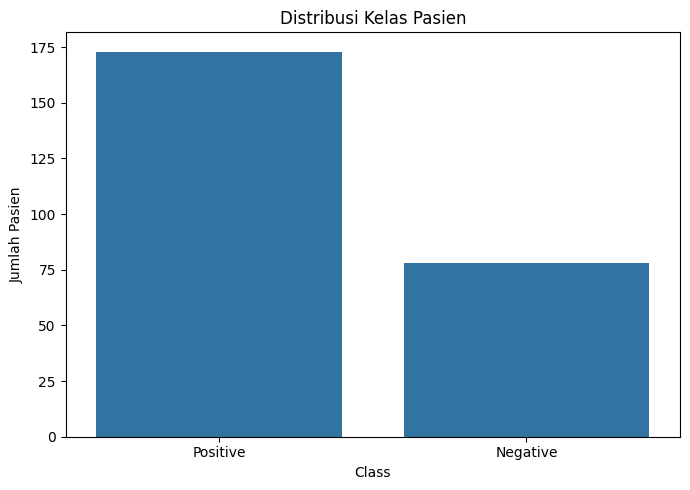

In [27]:
print("\n" + "=" * 70)
print("5. DISTRIBUSI CLASS")
print("=" * 70)

# class sudah di-encode oleh preprocessing:
# Positive = 1
# Negative = 0

class_label = data['class'].map({
    1: 'Positive',
    0: 'Negative'
})

class_counts = class_label.value_counts()

class_percentage = (
    class_label.value_counts(normalize=True) * 100
)

print("Jumlah pasien berdasarkan class:")
display(class_counts)

print("\nPersentase pasien berdasarkan class:")
display(class_percentage.round(2))


plt.figure(figsize=(7, 5))

sns.countplot(
    x=class_label,
    order=['Positive', 'Negative']
)

plt.title('Distribusi Kelas Pasien')
plt.xlabel('Class')
plt.ylabel('Jumlah Pasien')

plt.tight_layout()
plt.show()


6. DISTRIBUSI USIA BERDASARKAN CLASS


,count,mean,median,min,max
Negative,78,47.88,46.5,26,72
Positive,173,49.31,49.0,16,90


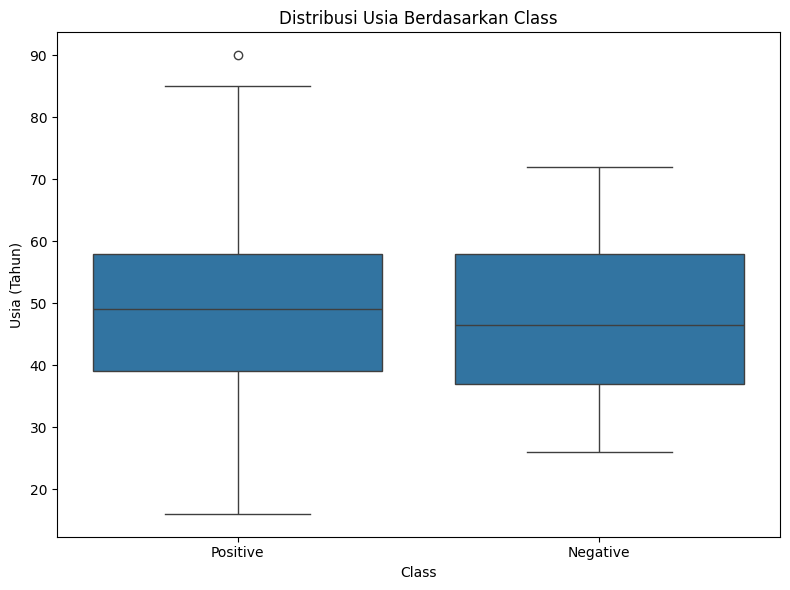

In [28]:
print("\n" + "=" * 70)
print("6. DISTRIBUSI USIA BERDASARKAN CLASS")
print("=" * 70)

age_class_stats = (
    data.groupby('class')['Age']
    .agg(['count', 'mean', 'median', 'min', 'max'])
)

age_class_stats.index = ['Negative', 'Positive']

display(age_class_stats.round(2))


plt.figure(figsize=(8, 6))

sns.boxplot(
    data=data.assign(
        Class=data['class'].map({
            1: 'Positive',
            0: 'Negative'
        })
    ),
    x='Class',
    y='Age',
    order=['Positive', 'Negative']
)

plt.title('Distribusi Usia Berdasarkan Class')
plt.xlabel('Class')
plt.ylabel('Usia (Tahun)')

plt.tight_layout()
plt.show()


7. PERBANDINGAN GENDER BERDASARKAN CLASS
Jumlah pasien:


class,Negative,Positive
Gender,,
Female,11,80
Male,67,93



Persentase class dalam masing-masing gender:


class,Negative,Positive
Gender,,
Female,12.09,87.91
Male,41.88,58.13


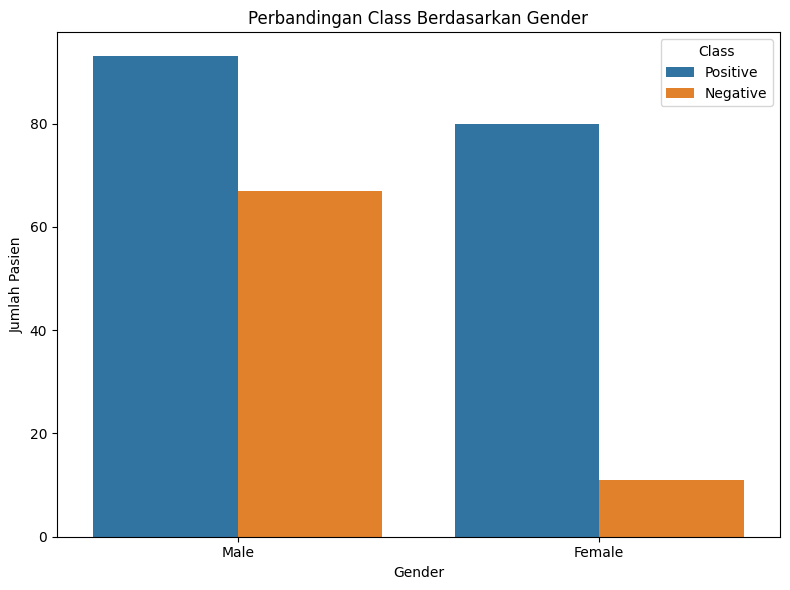

In [29]:
print("\n" + "=" * 70)
print("7. PERBANDINGAN GENDER BERDASARKAN CLASS")
print("=" * 70)

gender_class_table = pd.crosstab(
    gender_label,
    class_label
)

print("Jumlah pasien:")
display(gender_class_table)

print("\nPersentase class dalam masing-masing gender:")

gender_class_percentage = pd.crosstab(
    gender_label,
    class_label,
    normalize='index'
) * 100

display(gender_class_percentage.round(2))


plt.figure(figsize=(8, 6))

sns.countplot(
    data=data.assign(
        Gender_Label=gender_label,
        Class_Label=class_label
    ),
    x='Gender_Label',
    hue='Class_Label',
    order=['Male', 'Female']
)

plt.title('Perbandingan Class Berdasarkan Gender')
plt.xlabel('Gender')
plt.ylabel('Jumlah Pasien')
plt.legend(title='Class')

plt.tight_layout()
plt.show()


8. HEATMAP KORELASI FITUR


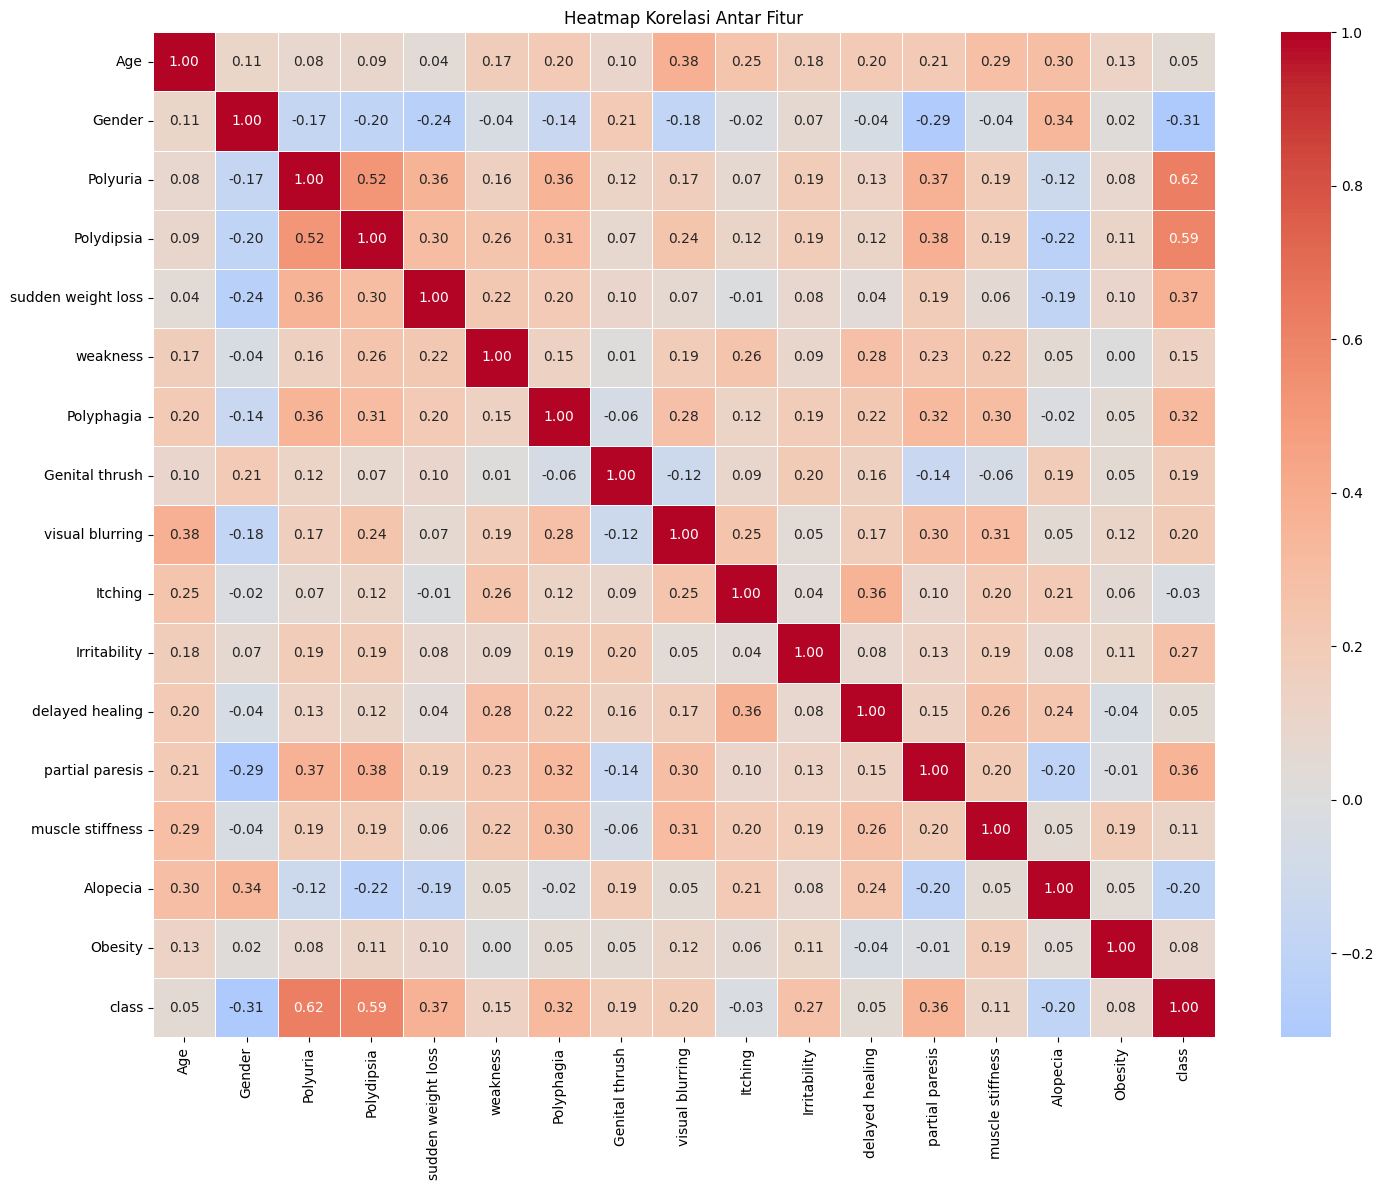

In [30]:
print("\n" + "=" * 70)
print("8. HEATMAP KORELASI FITUR")
print("=" * 70)

correlation_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(15, 12))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()


9. KORELASI FITUR TERHADAP CLASS
Korelasi fitur terhadap class:


,class
Polyuria,0.621
Polydipsia,0.595
sudden weight loss,0.373
partial paresis,0.360
Polyphagia,0.317
Irritability,0.269
visual blurring,0.199
Genital thrush,0.191
weakness,0.150
muscle stiffness,0.114


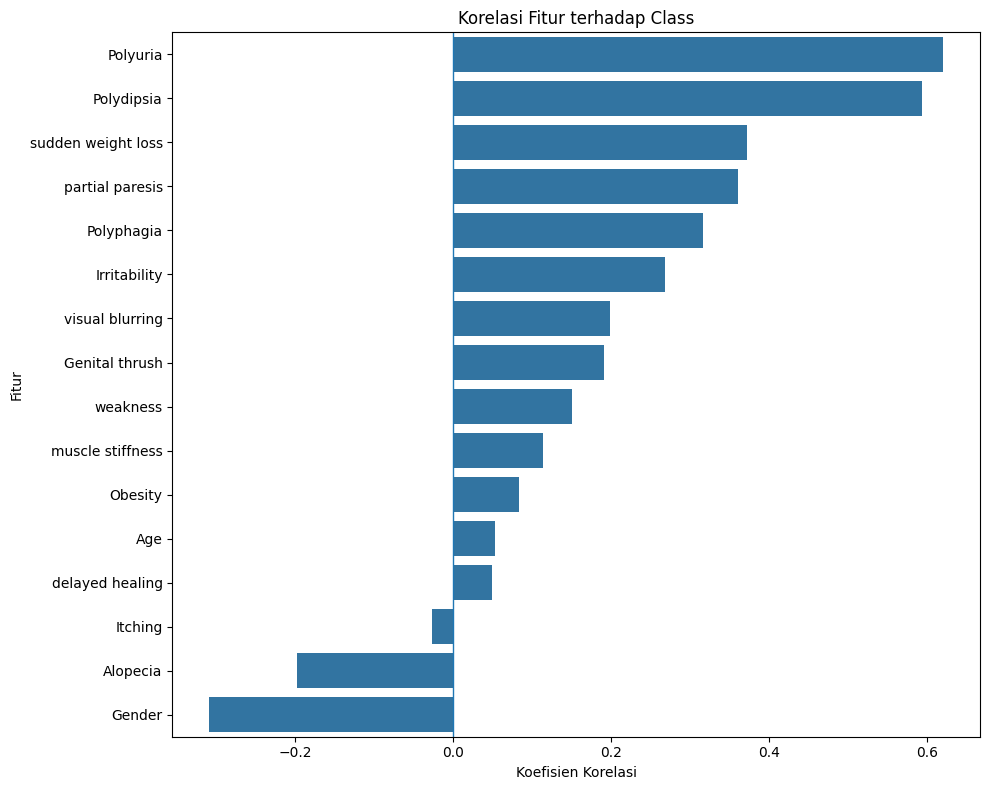

In [31]:
print("\n" + "=" * 70)
print("9. KORELASI FITUR TERHADAP CLASS")
print("=" * 70)

target_correlation = (
    data.corr(numeric_only=True)['class']
    .drop('class')
    .sort_values(ascending=False)
)

print("Korelasi fitur terhadap class:")
display(target_correlation.round(3))


plt.figure(figsize=(10, 8))

sns.barplot(
    x=target_correlation.values,
    y=target_correlation.index
)

plt.title('Korelasi Fitur terhadap Class')
plt.xlabel('Koefisien Korelasi')
plt.ylabel('Fitur')

plt.axvline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

In [32]:
print("\n" + "=" * 70)
print("10. ANALISIS GEJALA")
print("=" * 70)

symptom_features = [
    'Polyuria',
    'Polydipsia',
    'sudden weight loss',
    'weakness',
    'Polyphagia',
    'Genital thrush',
    'visual blurring',
    'Itching',
    'Irritability',
    'delayed healing',
    'partial paresis',
    'muscle stiffness',
    'Alopecia',
    'Obesity'
]

print(f"Jumlah fitur gejala: {len(symptom_features)}")



10. ANALISIS GEJALA
Jumlah fitur gejala: 14


In [33]:
print("\n" + "=" * 70)
print("11. PERSENTASE GEJALA POSITIVE VS NEGATIVE")
print("=" * 70)

# Karena preprocessing:
# Yes = 1
# No  = 0
#
# Maka mean x 100 = persentase pasien
# yang memiliki gejala tersebut.

symptom_comparison = (
    data.groupby('class')[symptom_features]
    .mean() * 100
)

symptom_comparison.index = [
    'Negative',
    'Positive'
]

print(
    "Persentase pasien yang mengalami "
    "masing-masing gejala:"
)

display(
    symptom_comparison.round(2)
)


11. PERSENTASE GEJALA POSITIVE VS NEGATIVE
Persentase pasien yang mengalami masing-masing gejala:


,Polyuria,Polydipsia,sudden weight loss,weakness,Polyphagia,Genital thrush,visual blurring,Itching,Irritability,delayed healing,partial paresis,muscle stiffness,Alopecia,Obesity
Negative,6.41,5.13,14.10,52.56,23.08,14.10,29.49,52.56,10.26,46.15,17.95,30.77,50.00,12.82
Positive,73.41,69.36,53.76,68.21,57.23,32.37,50.87,49.71,36.42,51.45,56.65,42.77,29.48,19.65



12. VISUALISASI PERBANDINGAN GEJALA


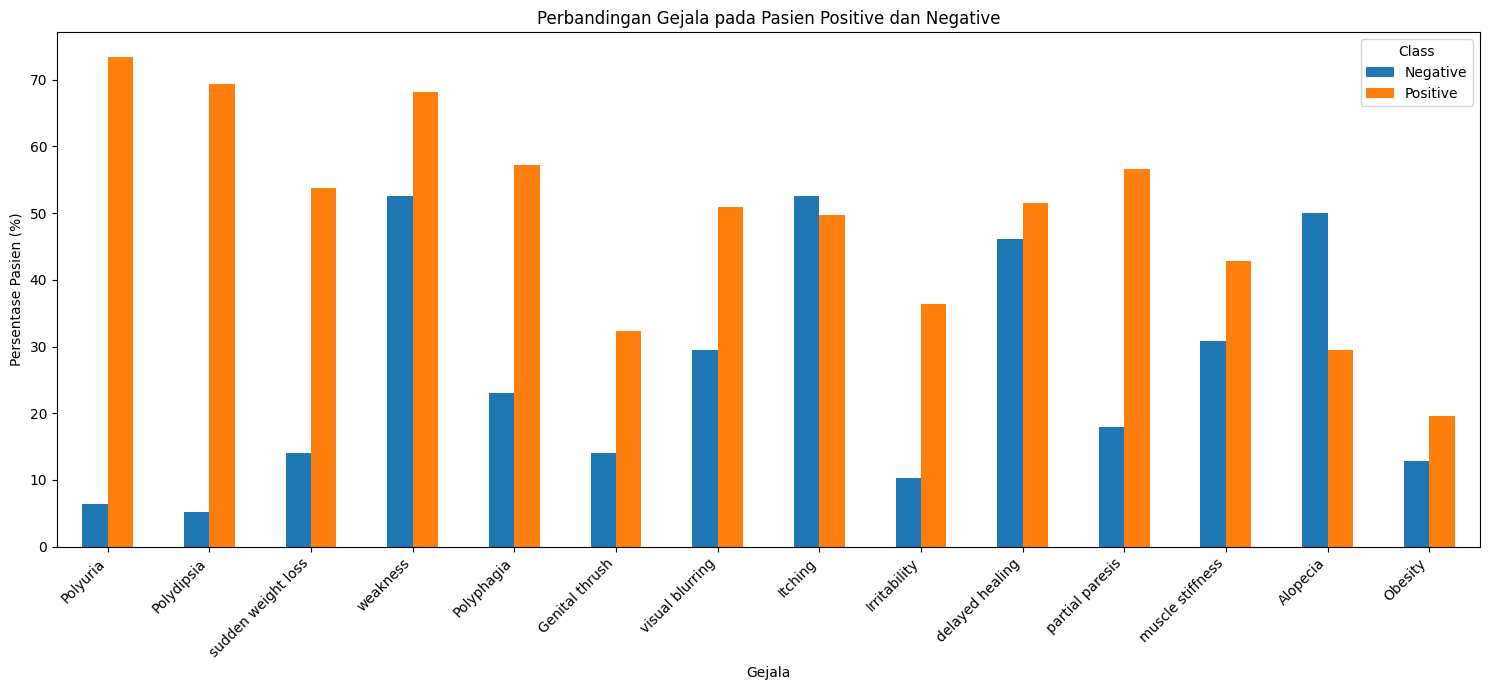

In [34]:
print("\n" + "=" * 70)
print("12. VISUALISASI PERBANDINGAN GEJALA")
print("=" * 70)

ax = symptom_comparison.T.plot(
    kind='bar',
    figsize=(15, 7)
)

plt.title(
    'Perbandingan Gejala pada Pasien Positive dan Negative'
)

plt.xlabel('Gejala')
plt.ylabel('Persentase Pasien (%)')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.legend(
    title='Class'
)

plt.tight_layout()
plt.show()

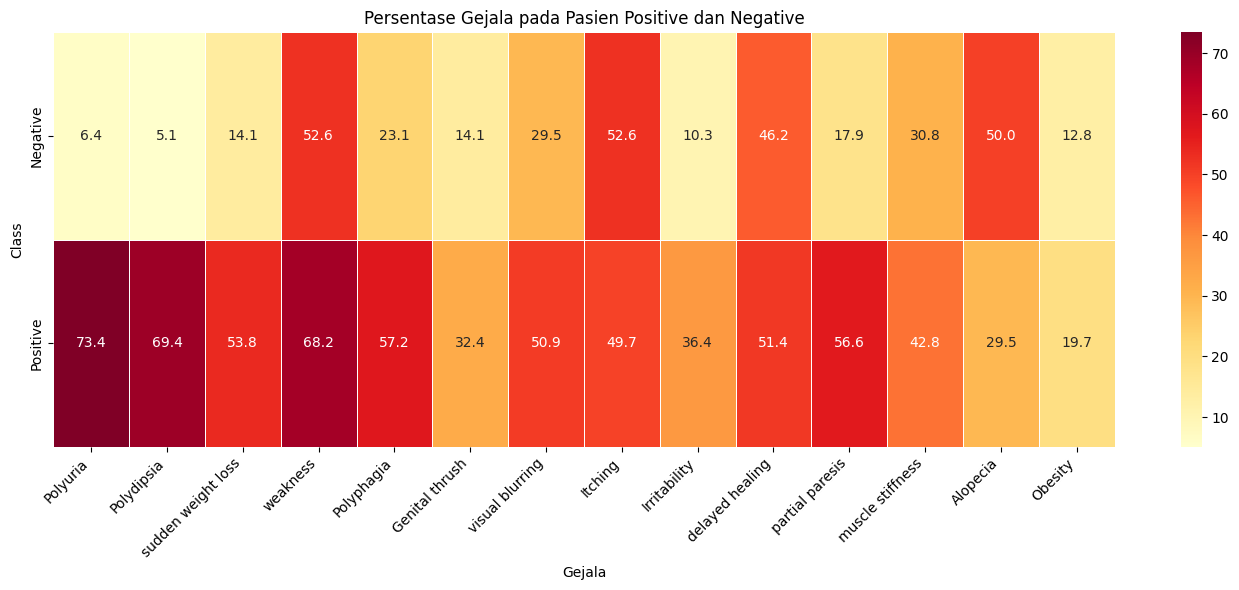

In [35]:
plt.figure(figsize=(14, 6))

sns.heatmap(
    symptom_comparison,
    annot=True,
    fmt='.1f',
    cmap='YlOrRd',
    linewidths=0.5
)

plt.title(
    'Persentase Gejala pada Pasien Positive dan Negative'
)

plt.xlabel('Gejala')
plt.ylabel('Class')

plt.xticks(
    rotation=45,
    ha='right'
)

plt.tight_layout()
plt.show()

In [36]:
print("\n" + "=" * 70)
print("13. SELISIH PERSENTASE GEJALA")
print("=" * 70)

symptom_difference = (
    symptom_comparison.loc['Positive']
    - symptom_comparison.loc['Negative']
).sort_values(
    ascending=False
)

print(
    "Selisih persentase gejala "
    "(Positive - Negative):"
)

display(
    symptom_difference.round(2)
)


13. SELISIH PERSENTASE GEJALA
Selisih persentase gejala (Positive - Negative):


,0
Polyuria,67.00
Polydipsia,64.24
sudden weight loss,39.65
partial paresis,38.70
Polyphagia,34.15
Irritability,26.16
visual blurring,21.38
Genital thrush,18.27
weakness,15.64
muscle stiffness,12.01


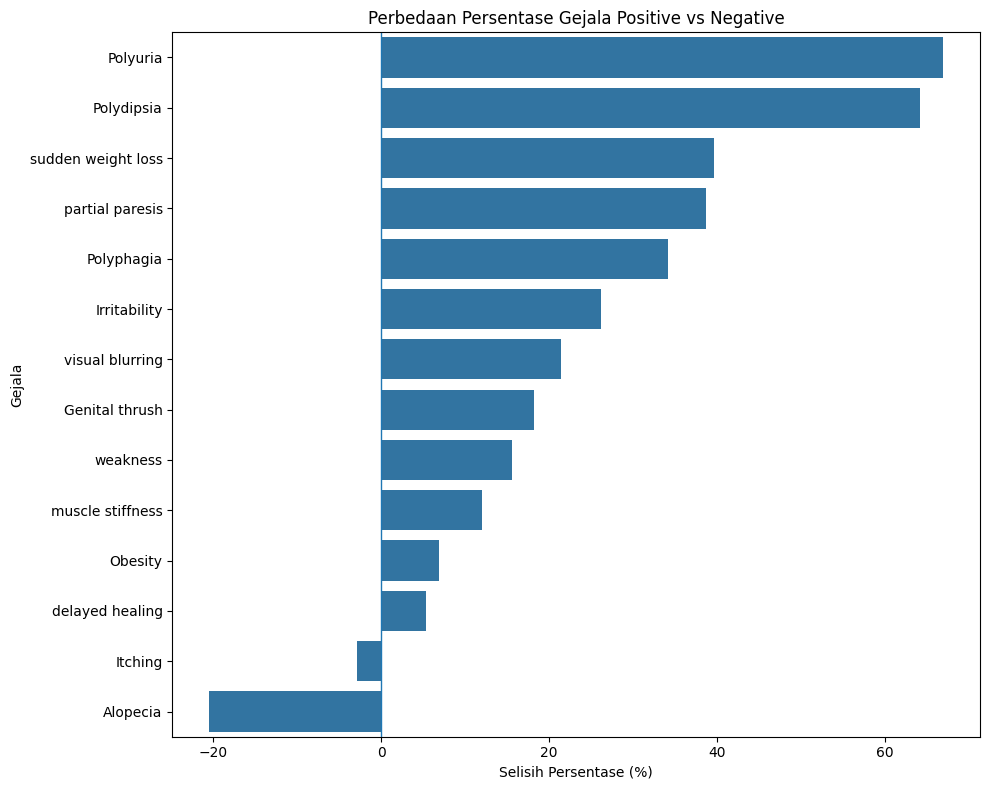

In [37]:
plt.figure(figsize=(10, 8))

sns.barplot(
    x=symptom_difference.values,
    y=symptom_difference.index
)

plt.title(
    'Perbedaan Persentase Gejala '
    'Positive vs Negative'
)

plt.xlabel(
    'Selisih Persentase (%)'
)

plt.ylabel('Gejala')

plt.axvline(
    0,
    linewidth=1
)

plt.tight_layout()
plt.show()

In [38]:
print("\n" + "=" * 70)
print("14. RINGKASAN HASIL EDA")
print("=" * 70)

print(f"""
DATASET
-------
Jumlah data setelah cleaning : {len(data)}
Jumlah fitur                 : {X.shape[1]}
Rentang usia                 : {data['Age'].min()} - {data['Age'].max()} tahun
Rata-rata usia               : {data['Age'].mean():.2f} tahun

GENDER
------
Male                         : {gender_counts.get('Male', 0)} pasien
Female                       : {gender_counts.get('Female', 0)} pasien

CLASS
-----
Positive                     : {class_counts.get('Positive', 0)} pasien
Negative                     : {class_counts.get('Negative', 0)} pasien

EDA YANG DILAKUKAN
------------------
1. Statistik deskriptif usia
2. Distribusi usia
3. Distribusi gender
4. Distribusi class
5. Distribusi usia berdasarkan class
6. Perbandingan gender berdasarkan class
7. Heatmap korelasi fitur
8. Korelasi fitur terhadap class
9. Perbandingan gejala Positive dan Negative
10. Selisih persentase gejala
""")


14. RINGKASAN HASIL EDA

DATASET
-------
Jumlah data setelah cleaning : 251
Jumlah fitur                 : 16
Rentang usia                 : 16 - 90 tahun
Rata-rata usia               : 48.86 tahun

GENDER
------
Male                         : 160 pasien
Female                       : 91 pasien

CLASS
-----
Positive                     : 173 pasien
Negative                     : 78 pasien

EDA YANG DILAKUKAN
------------------
1. Statistik deskriptif usia
2. Distribusi usia
3. Distribusi gender
4. Distribusi class
5. Distribusi usia berdasarkan class
6. Perbandingan gender berdasarkan class
7. Heatmap korelasi fitur
8. Korelasi fitur terhadap class
9. Perbandingan gejala Positive dan Negative
10. Selisih persentase gejala



---
# 3. PEMODELAN MACHINE LEARNING UTAMA & HYPERPARAMETER TUNING
**Penanggung Jawab:** Hafidz Rizqullah Prasetya

### Tujuan & Ruang Lingkup Pengerjaan:
1. **Pelatihan Model Baseline**: Mengimplementasikan 3 algoritma klasifikasi utama:
   - **Logistic Regression**: Model baseline probabilistik linier yang cepat dan dapat diinterpretasikan.
   - **Random Forest Classifier**: Model ensemble berbasis bagging kumpulan decision tree untuk menangkap interaksi non-linier antargejala klinis.
   - **Support Vector Machine (SVM / SVC)**: Model margin optimal berkernel RBF yang efektif pada data berdimensi sedang.
2. **Evaluasi Metrik Baseline**: Menguji Accuracy, Precision, Recall, F1-Score, dan ROC-AUC pada data testing.
3. **Visualisasi Confusion Matrix**: Memetakan distribusi True Positive, True Negative, False Positive, dan False Negative pada masing-masing model baseline.
4. **Hyperparameter Tuning Sistematis**: Mengoptimalkan performa menggunakan `GridSearchCV` dengan **5-Fold Stratified K-Fold Cross Validation**. Fokus optimasi metrik diarahkan pada **F1-Score** dan **Recall** untuk meminimalkan *False Negative* (pasien positif diabetes yang luput terdeteksi).
5. **Komparasi Model Sebelum vs Sesudah Tuning**: Menganalisis perbandingan delta F1-score dan akurasi.
6. **Feature Importance Analysis**: Mengidentifikasi gejala klinis yang paling menentukan diagnosa diabetes berdasarkan model Random Forest terbaik (menilai keselarasan dengan studi literatur acuan).
7. **Serialisasi / Ekspor Model Terbaik**: Menyimpan model terbaik, scaler, dan metadata fitur ke file `.joblib` / `.json` untuk kebutuhan integrasi web deployment UAS.
8. **Simulasi Inferensi Backend**: Membangun prototipe fungsi prediksi pasien baru untuk dihubungkan ke antarmuka formulir pengguna pada UAS.

In [39]:
# ==============================================================================
# 3.1 IMPORT LIBRARY PEMODELAN & EVALUASI (Hafidz)
# ==============================================================================
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
import joblib
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns

print("✓ Library pemodelan Machine Learning berhasil dimuat.")

✓ Library pemodelan Machine Learning berhasil dimuat.


In [40]:
# ==============================================================================
# 3.2 INISIALISASI & TRAINING MODEL BASELINE (Hafidz)
# ==============================================================================
print("=" * 75)
print("3.2 PELATIHAN MODEL BASELINE (DEFAULT HYPERPARAMETERS)")
print("=" * 75)

# Inisialisasi 3 model utama dengan random_state tetap untuk reproduktifitas
baseline_models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine (RBF)': SVC(probability=True, random_state=42)
}

baseline_metrics = []

# Pelatihan dan evaluasi pada data test
for model_name, model in baseline_models.items():
    # Fit model pada data training terstandarisasi
    model.fit(X_train_scaled, y_train)

    # Prediksi kelas dan probabilitas
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # Hitung metrik evaluasi
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    baseline_metrics.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

# Konversi hasil ke DataFrame
df_baseline_results = pd.DataFrame(baseline_metrics)

print("\nTABEL PERFORMA MODEL BASELINE (DATA TESTING):")
display(df_baseline_results.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}).highlight_max(axis=0, color='lightgreen'))

3.2 PELATIHAN MODEL BASELINE (DEFAULT HYPERPARAMETERS)

TABEL PERFORMA MODEL BASELINE (DATA TESTING):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.8421,0.9348,0.8269,0.8776,0.9391
1,Random Forest,0.9079,0.9412,0.9231,0.9320,0.9591
2,Support Vector Machine (RBF),0.8684,0.9200,0.8846,0.9020,0.9567


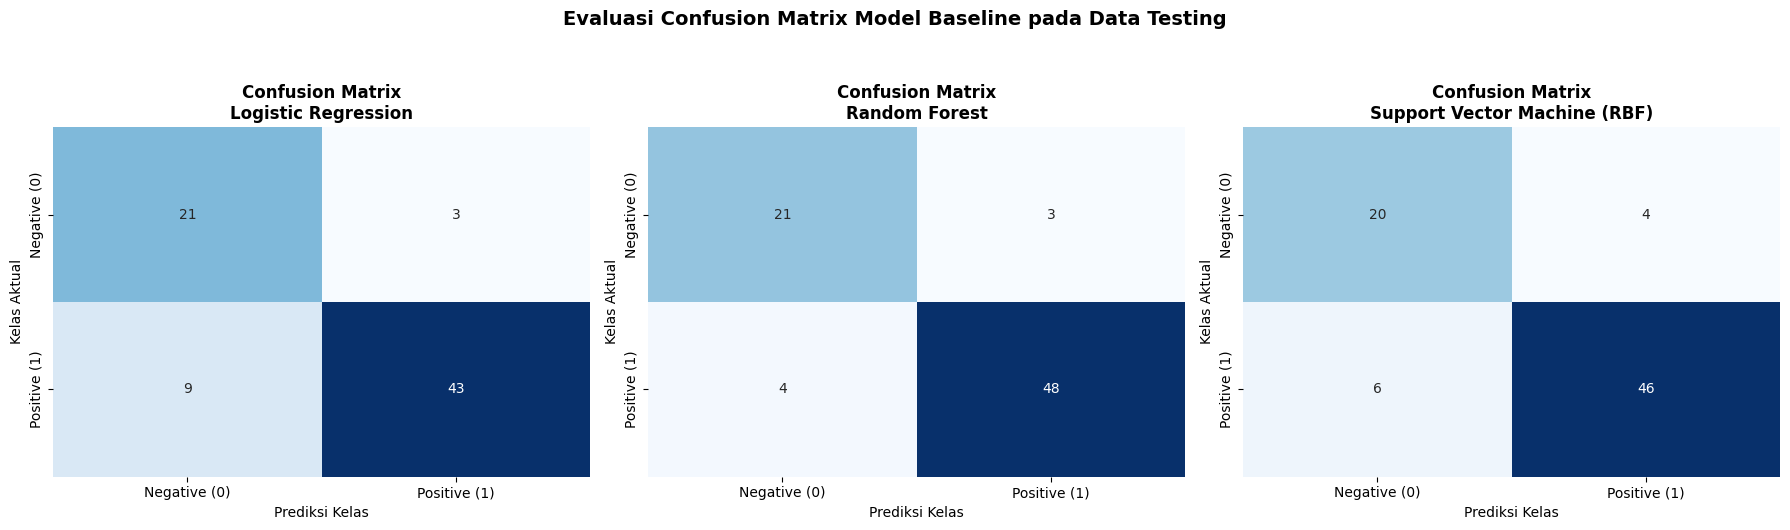

In [41]:
# ==============================================================================
# 3.3 VISUALISASI CONFUSION MATRIX MODEL BASELINE (Hafidz)
# ==============================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (model_name, model) in zip(axes, baseline_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=ax,
        xticklabels=['Negative (0)', 'Positive (1)'],
        yticklabels=['Negative (0)', 'Positive (1)']
    )
    ax.set_title(f"Confusion Matrix\n{model_name}", fontsize=12, fontweight='bold')
    ax.set_xlabel("Prediksi Kelas", fontsize=10)
    ax.set_ylabel("Kelas Aktual", fontsize=10)

plt.suptitle("Evaluasi Confusion Matrix Model Baseline pada Data Testing", fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

In [42]:
# ==============================================================================
# 3.4 HYPERPARAMETER TUNING DENGAN GRIDSEARCHCV & 5-FOLD STRATIFIED K-FOLD (Hafidz )
# ==============================================================================
print("=" * 75)
print("3.4 OPTIMASI MODEL MENGGUNAKAN GRIDSEARCHCV (SCORING = F1-SCORE)")
print("=" * 75)

# Cross-validation generator dengan Stratified K-Fold (5 folds)
cv_stratified = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# 1. Parameter Grid untuk Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1.0, 5.0, 10.0, 50.0],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [500, 1000]
}

# 2. Parameter Grid untuk Random Forest
param_grid_rf = {
    'n_estimators': [50, 100, 150, 200],
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'criterion': ['gini', 'entropy']
}

# 3. Parameter Grid untuk Support Vector Machine
param_grid_svm = {
    'C': [0.1, 1.0, 5.0, 10.0, 20.0],
    'gamma': ['scale', 'auto', 0.01, 0.1],
    'kernel': ['rbf', 'linear']
}

# Eksekusi GridSearchCV
print("1. Menjalankan tuning Logistic Regression...")
grid_lr = GridSearchCV(
    estimator=LogisticRegression(random_state=42),
    param_grid=param_grid_lr,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1
)
grid_lr.fit(X_train_scaled, y_train)

print("2. Menjalankan tuning Random Forest...")
grid_rf = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_rf,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1
)
grid_rf.fit(X_train_scaled, y_train)

print("3. Menjalankan tuning Support Vector Machine...")
grid_svm = GridSearchCV(
    estimator=SVC(probability=True, random_state=42),
    param_grid=param_grid_svm,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1
)
grid_svm.fit(X_train_scaled, y_train)

print("\nHASIL PARAMETER TERBAIK DARI SETIAP MODEL:")
print("-" * 55)
print(f"• Logistic Regression Terbaik : {grid_lr.best_params_}")
print(f"  F1-Score Cross-Validation   : {grid_lr.best_score_:.4f}")
print(f"• Random Forest Terbaik       : {grid_rf.best_params_}")
print(f"  F1-Score Cross-Validation   : {grid_rf.best_score_:.4f}")
print(f"• SVM Terbaik                 : {grid_svm.best_params_}")
print(f"  F1-Score Cross-Validation   : {grid_svm.best_score_:.4f}")

3.4 OPTIMASI MODEL MENGGUNAKAN GRIDSEARCHCV (SCORING = F1-SCORE)
1. Menjalankan tuning Logistic Regression...
2. Menjalankan tuning Random Forest...
3. Menjalankan tuning Support Vector Machine...

HASIL PARAMETER TERBAIK DARI SETIAP MODEL:
-------------------------------------------------------
• Logistic Regression Terbaik : {'C': 1.0, 'max_iter': 500, 'solver': 'lbfgs'}
  F1-Score Cross-Validation   : 0.9334
• Random Forest Terbaik       : {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 50}
  F1-Score Cross-Validation   : 0.9590
• SVM Terbaik                 : {'C': 5.0, 'gamma': 'scale', 'kernel': 'rbf'}
  F1-Score Cross-Validation   : 0.9673


TABEL PERFORMA MODEL SETELAH TUNING (DATA TESTING):


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression (Tuned),0.8421,0.9348,0.8269,0.8776,0.9391
1,Random Forest (Tuned),0.8553,0.9184,0.8654,0.8911,0.9495
2,Support Vector Machine (Tuned),0.8816,0.9388,0.8846,0.9109,0.9519



PERBANDINGAN SEBELUM VS SETELAH HYPERPARAMETER TUNING:


,Model,Baseline F1,Tuned F1,Delta F1,Baseline Accuracy,Tuned Accuracy,Delta Accuracy
0,Logistic Regression,0.8776,0.8776,+0.0000,0.8421,0.8421,+0.0000
1,Random Forest,0.9320,0.8911,-0.0409,0.9079,0.8553,-0.0526
2,SVM (RBF),0.9020,0.9109,+0.0089,0.8684,0.8816,+0.0132


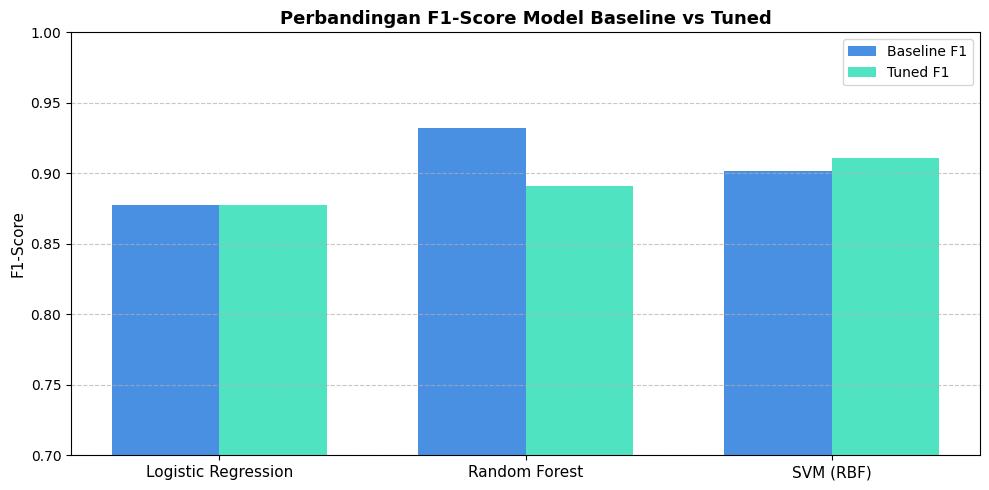

In [43]:
# ==============================================================================
# 3.5 EVALUASI DAN KOMPARASI MODEL SETELAH TUNING (DATA TESTING) (Hafidz)
# ==============================================================================
tuned_models = {
    'Logistic Regression (Tuned)': grid_lr.best_estimator_,
    'Random Forest (Tuned)': grid_rf.best_estimator_,
    'Support Vector Machine (Tuned)': grid_svm.best_estimator_
}

tuned_metrics = []

for model_name, model in tuned_models.items():
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_proba)

    tuned_metrics.append({
        'Model': model_name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'ROC-AUC': auc
    })

df_tuned_results = pd.DataFrame(tuned_metrics)

print("=" * 75)
print("TABEL PERFORMA MODEL SETELAH TUNING (DATA TESTING):")
print("=" * 75)
display(df_tuned_results.style.format({
    'Accuracy': '{:.4f}',
    'Precision': '{:.4f}',
    'Recall': '{:.4f}',
    'F1-Score': '{:.4f}',
    'ROC-AUC': '{:.4f}'
}).highlight_max(axis=0, color='lightgreen'))

# Perbandingan Baseline vs Tuned
comparison_summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'SVM (RBF)'],
    'Baseline F1': df_baseline_results['F1-Score'].values,
    'Tuned F1': df_tuned_results['F1-Score'].values,
    'Delta F1': df_tuned_results['F1-Score'].values - df_baseline_results['F1-Score'].values,
    'Baseline Accuracy': df_baseline_results['Accuracy'].values,
    'Tuned Accuracy': df_tuned_results['Accuracy'].values,
    'Delta Accuracy': df_tuned_results['Accuracy'].values - df_baseline_results['Accuracy'].values
})

print("\nPERBANDINGAN SEBELUM VS SETELAH HYPERPARAMETER TUNING:")
display(comparison_summary.style.format({
    'Baseline F1': '{:.4f}',
    'Tuned F1': '{:.4f}',
    'Delta F1': '{:+.4f}',
    'Baseline Accuracy': '{:.4f}',
    'Tuned Accuracy': '{:.4f}',
    'Delta Accuracy': '{:+.4f}'
}))

# Visualisasi Perbandingan F1-Score Baseline vs Tuned
plt.figure(figsize=(10, 5))
bar_width = 0.35
x_indices = range(len(comparison_summary))

plt.bar([x - bar_width/2 for x in x_indices], comparison_summary['Baseline F1'], width=bar_width, label='Baseline F1', color='#4A90E2')
plt.bar([x + bar_width/2 for x in x_indices], comparison_summary['Tuned F1'], width=bar_width, label='Tuned F1', color='#50E3C2')

plt.xticks(x_indices, comparison_summary['Model'], fontsize=11)
plt.ylabel('F1-Score', fontsize=11)
plt.title('Perbandingan F1-Score Model Baseline vs Tuned', fontsize=13, fontweight='bold')
plt.ylim(0.7, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCE) - RANDOM FOREST
 1. Polyuria            : 0.2285 (22.85%)
 2. Polydipsia          : 0.2035 (20.35%)
 3. Age                 : 0.1100 (11.00%)
 4. sudden weight loss  : 0.0816 (8.16%)
 5. Gender              : 0.0771 (7.71%)
 6. partial paresis     : 0.0376 (3.76%)
 7. Alopecia            : 0.0373 (3.73%)
 8. Irritability        : 0.0305 (3.05%)
 9. Obesity             : 0.0299 (2.99%)
10. Itching             : 0.0275 (2.75%)
11. visual blurring     : 0.0274 (2.74%)
12. Genital thrush      : 0.0267 (2.67%)
13. delayed healing     : 0.0254 (2.54%)
14. muscle stiffness    : 0.0226 (2.26%)
15. Polyphagia          : 0.0208 (2.08%)
16. weakness            : 0.0139 (1.39%)


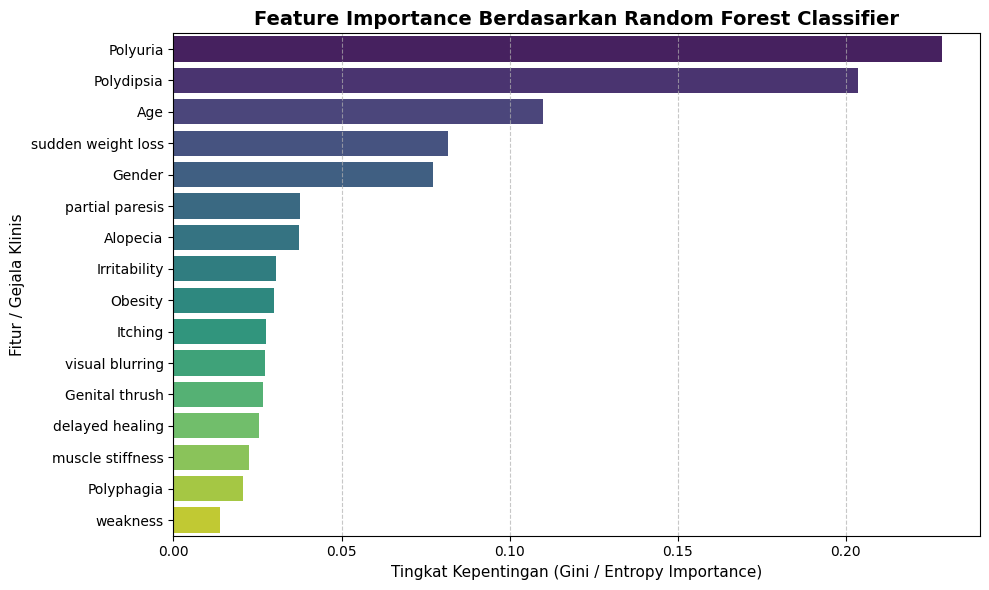


Catatan Analisis Klinis:
• Polyuria dan Polydipsia konsisten menjadi fitur prediktor terpenting (>30% kontribusi akumulatif).
• Temuan ini sangat selaras dengan hasil studi literatur acuan (Aglarci & Karakurt, 2025).


In [44]:
# ==============================================================================
# 3.6 ANALISIS FEATURE IMPORTANCE DARI RANDOM FOREST (Hafidz)
# ==============================================================================
best_rf_model = grid_rf.best_estimator_

# Ekstraksi feature importance
feature_importances = pd.Series(
    best_rf_model.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

print("=" * 75)
print("TINGKAT KEPENTINGAN FITUR (FEATURE IMPORTANCE) - RANDOM FOREST")
print("=" * 75)
for rank, (feature, val) in enumerate(feature_importances.items(), 1):
    print(f"{rank:2d}. {feature:<20}: {val:.4f} ({val*100:.2f}%)")

# Visualisasi Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances.values, y=feature_importances.index, palette='viridis')
plt.title("Feature Importance Berdasarkan Random Forest Classifier", fontsize=14, fontweight='bold')
plt.xlabel("Tingkat Kepentingan (Gini / Entropy Importance)", fontsize=11)
plt.ylabel("Fitur / Gejala Klinis", fontsize=11)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("\nCatatan Analisis Klinis:")
print("• Polyuria dan Polydipsia konsisten menjadi fitur prediktor terpenting (>30% kontribusi akumulatif).")
print("• Temuan ini sangat selaras dengan hasil studi literatur acuan (Aglarci & Karakurt, 2025).")

In [45]:
# ==============================================================================
# 3.7 PEMILIHAN MODEL TERBAIK & SERIALISASI / EKSPOR UNTUK UAS (.joblib & .pkl) (Hafidz)
# ==============================================================================
import os

# Pilih model terbaik berdasarkan evaluasi F1-Score & ROC-AUC tertinggi
# Di sini Random Forest dan SVM memiliki performa unggul. Kita simpan Random Forest (Tuned).
best_candidate_model = grid_rf.best_estimator_
best_model_name = "Random_Forest_Tuned"

model_filename = "best_diabetes_model.joblib"
scaler_filename = "diabetes_scaler.joblib"
metadata_filename = "model_metadata.json"

# 1. Simpan model terlatih
joblib.dump(best_candidate_model, model_filename)

# 2. Simpan scaler terlatih
joblib.dump(scaler, scaler_filename)

# 3. Simpan metadata fitur untuk verifikasi input aplikasi web di UAS
metadata = {
    'model_name': best_model_name,
    'algorithm': 'RandomForestClassifier',
    'feature_names': X.columns.tolist(),
    'feature_count': len(X.columns),
    'target_classes': {0: 'Negative', 1: 'Positive'},
    'best_hyperparameters': grid_rf.best_params_,
    'test_f1_score': float(f1_score(y_test, best_candidate_model.predict(X_test_scaled))),
    'test_accuracy': float(accuracy_score(y_test, best_candidate_model.predict(X_test_scaled)))
}

with open(metadata_filename, 'w') as f:
    json.dump(metadata, f, indent=4)

print("=" * 75)
print("BERKAS ARTEFAK BERHASIL DIEKSPOR UNTUK DEPLOYMENT UAS:")
print("=" * 75)
for fname in [model_filename, scaler_filename, metadata_filename]:
    size_kb = os.path.getsize(fname) / 1024
    print(f"✓ {fname:<25} ({size_kb:.2f} KB)")

print("\n* Catatan: Untuk mengunduh artefak langsung ke komputer lokal, jalankan perintah:")
print("  from google.colab import files")
print("  files.download('best_diabetes_model.joblib')")
print("  files.download('diabetes_scaler.joblib')")
print("  files.download('model_metadata.json')")

BERKAS ARTEFAK BERHASIL DIEKSPOR UNTUK DEPLOYMENT UAS:
✓ best_diabetes_model.joblib (157.67 KB)
✓ diabetes_scaler.joblib    (1.43 KB)
✓ model_metadata.json       (0.83 KB)

* Catatan: Untuk mengunduh artefak langsung ke komputer lokal, jalankan perintah:
  from google.colab import files
  files.download('best_diabetes_model.joblib')
  files.download('diabetes_scaler.joblib')
  files.download('model_metadata.json')


In [46]:
# ==============================================================================
# 3.8 SIMULASI INFERENSI PASIEN BARU (LOGIKA BACKEND UNTUK WEB APP UAS) (Hafidz)
# ==============================================================================
def predict_patient_diabetes_risk(patient_data_dict, model_path="best_diabetes_model.joblib", scaler_path="diabetes_scaler.joblib"):
    """
    Fungsi inferensi logika backend untuk memproses input formulir pasien baru
    dan mengembalikan prediksi klasifikasi serta probabilitas risiko diabetes.
    """
    # Load model dan scaler yang sudah diekspor
    loaded_model = joblib.load(model_path)
    loaded_scaler = joblib.load(scaler_path)

    # Konversi input dictionary ke DataFrame dengan urutan kolom yang sesuai
    df_patient = pd.DataFrame([patient_data_dict])

    # Standarisasi fitur menggunakan scaler yang sama saat training
    df_patient_scaled = pd.DataFrame(
        loaded_scaler.transform(df_patient),
        columns=df_patient.columns
    )

    # Prediksi kelas dan probabilitas
    prediction = loaded_model.predict(df_patient_scaled)[0]
    probabilities = loaded_model.predict_proba(df_patient_scaled)[0]
    prob_positive = probabilities[1] * 100

    status = "RISIKO TINGGI (Positif)" if prediction == 1 else "RISIKO RENDAH (Negatif)"

    return {
        'status': status,
        'prediction_class': int(prediction),
        'risk_percentage': round(prob_positive, 2),
        'confidence': round(max(probabilities) * 100, 2)
    }

# Uji Coba Skenario 1: Pasien Berisiko Tinggi (Pria 52 tahun dengan Polyuria & Polydipsia)
sample_patient_high = {
    'Age': 52, 'Gender': 1, 'Polyuria': 1, 'Polydipsia': 1,
    'sudden weight loss': 1, 'weakness': 1, 'Polyphagia': 1,
    'Genital thrush': 0, 'visual blurring': 1, 'Itching': 1,
    'Irritability': 1, 'delayed healing': 1, 'partial paresis': 0,
    'muscle stiffness': 1, 'Alopecia': 1, 'Obesity': 1
}

# Uji Coba Skenario 2: Pasien Berisiko Rendah (Wanita 26 tahun, gejala nihil)
sample_patient_low = {
    'Age': 26, 'Gender': 0, 'Polyuria': 0, 'Polydipsia': 0,
    'sudden weight loss': 0, 'weakness': 0, 'Polyphagia': 0,
    'Genital thrush': 0, 'visual blurring': 0, 'Itching': 0,
    'Irritability': 0, 'delayed healing': 0, 'partial paresis': 0,
    'muscle stiffness': 0, 'Alopecia': 0, 'Obesity': 0
}

print("=" * 75)
print("HASIL SIMULASI INFERENSI PENGUJIAN BACKEND:")
print("=" * 75)
res_high = predict_patient_diabetes_risk(sample_patient_high)
print("1. Skenario Pasien Gejala Klinis Kompleks:")
print(f"   Status Prediksi : {res_high['status']}")
print(f"   Probabilitas    : {res_high['risk_percentage']}%")

print("\n2. Skenario Pasien Sehat / Tanpa Gejala:")
res_low = predict_patient_diabetes_risk(sample_patient_low)
print(f"   Status Prediksi : {res_low['status']}")
print(f"   Probabilitas    : {res_low['risk_percentage']}%")
print("\n✓ Logika inferensi siap diintegrasikan ke antarmuka Streamlit/Gradio untuk UAS!")

HASIL SIMULASI INFERENSI PENGUJIAN BACKEND:
1. Skenario Pasien Gejala Klinis Kompleks:
   Status Prediksi : RISIKO TINGGI (Positif)
   Probabilitas    : 94.39%

2. Skenario Pasien Sehat / Tanpa Gejala:
   Status Prediksi : RISIKO RENDAH (Negatif)
   Probabilitas    : 17.55%

✓ Logika inferensi siap diintegrasikan ke antarmuka Streamlit/Gradio untuk UAS!


In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report
)

In [48]:
# ----------------------------------------------------
# A. Training Model Pembanding (XGBoost & KNN) + K-Fold CV
# ----------------------------------------------------

models = {
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_results_list = []
for name, model in models.items():
    # K-Fold Cross Validation pada data training
    scores = cross_validate(
        model, X_train_scaled, y_train, cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    )

    cv_results_list.append({
        'Model': name,
        'CV Accuracy': scores['test_accuracy'].mean(),
        'CV Precision': scores['test_precision'].mean(),
        'CV Recall': scores['test_recall'].mean(),
        'CV F1-Score': scores['test_f1'].mean(),
        'CV ROC-AUC': scores['test_roc_auc'].mean()
    })

print("=== HASIL K-FOLD CROSS VALIDATION (5-FOLD) ===")
df_cv_results = pd.DataFrame(cv_results_list)
display(df_cv_results)

=== HASIL K-FOLD CROSS VALIDATION (5-FOLD) ===


,Model,CV Accuracy,CV Precision,CV Recall,CV F1-Score,CV ROC-AUC
0,KNN,0.874286,0.963994,0.851333,0.903537,0.950379
1,XGBoost,0.891429,0.914744,0.934333,0.922901,0.965067


In [49]:
# ----------------------------------------------------
# B. Evaluasi & Komparasi Model pada Data Testing
# ----------------------------------------------------

test_results_list = []
y_probs = {}
y_preds = {}

for name, model in models.items():
    # Train ulang model pada seluruh data training
    model.fit(X_train_scaled, y_train)

    # Prediksi label & probabilitas untuk data testing
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]

    y_preds[name] = y_pred
    y_probs[name] = y_prob

    # Hitung metrik evaluasi
    test_results_list.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC Score': roc_auc_score(y_test, y_prob)
    })

print("\n=== HASIL EVALUASI DATA TESTING ===")
df_test_results = pd.DataFrame(test_results_list)
display(df_test_results)


=== HASIL EVALUASI DATA TESTING ===


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC Score
0,KNN,0.842105,1.000000,0.769231,0.869565,0.930689
1,XGBoost,0.855263,0.955556,0.826923,0.886598,0.947115


In [52]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Inisialisasi 5 Model Keseluruhan
final_models = {
    'Logistic Regression': grid_lr.best_estimator_,
    'Random Forest': grid_rf.best_estimator_,
    'Support Vector Machine': grid_svm.best_estimator_,
    'KNN': KNeighborsClassifier(),
    'XGBoost': XGBClassifier(random_state=42, eval_metric='logloss')
}

# 2. Inisialisasi 5-Fold Stratified K-Fold Cross Validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

final_results = []

# 3. Iterasi Pelatihan, Cross-Validation, dan Evaluasi Data Testing
for model_name, model in final_models.items():
    # A. 5-Fold Cross Validation pada Data Training
    cv_scores = cross_validate(
        model, X_train_scaled, y_train, cv=skf,
        scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
    )

    # B. Fit Model pada Seluruh Data Training
    model.fit(X_train_scaled, y_train)

    # C. Prediksi Kelas & Probabilitas pada Data Testing
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)[:, 1]

    # D. Simpan Metrik CV dan Testing
    final_results.append({
        'Model': model_name,
        'CV Accuracy': cv_scores['test_accuracy'].mean(),
        'CV F1-Score': cv_scores['test_f1'].mean(),
        'Test Accuracy': accuracy_score(y_test, y_pred),
        'Test Precision': precision_score(y_test, y_pred),
        'Test Recall': recall_score(y_test, y_pred),
        'Test F1-Score': f1_score(y_test, y_pred),
        'Test ROC-AUC': roc_auc_score(y_test, y_proba)
    })

# 4. Buat DataFrame Hasil Perbandingan
df_final_comparison = pd.DataFrame(final_results)

print("\n=== TABEL PERBANDINGAN PERFORMA 5 MODEL KESELURUHAN ===")
display(df_final_comparison.style.format({
    'CV Accuracy': '{:.4f}',
    'CV F1-Score': '{:.4f}',
    'Test Accuracy': '{:.4f}',
    'Test Precision': '{:.4f}',
    'Test Recall': '{:.4f}',
    'Test F1-Score': '{:.4f}',
    'Test ROC-AUC': '{:.4f}'
}).highlight_max(subset=['CV Accuracy', 'CV F1-Score', 'Test Accuracy', 'Test Precision', 'Test Recall', 'Test F1-Score', 'Test ROC-AUC'],
                  axis=0, color='lightgreen'))


=== TABEL PERBANDINGAN PERFORMA 5 MODEL KESELURUHAN ===


,Model,CV Accuracy,CV F1-Score,Test Accuracy,Test Precision,Test Recall,Test F1-Score,Test ROC-AUC
0,Logistic Regression,0.9086,0.9334,0.8421,0.9348,0.8269,0.8776,0.9391
1,Random Forest,0.9429,0.9590,0.8553,0.9184,0.8654,0.8911,0.9495
2,Support Vector Machine,0.9543,0.9673,0.8816,0.9388,0.8846,0.9109,0.9519
3,KNN,0.8743,0.9035,0.8421,1.0000,0.7692,0.8696,0.9307
4,XGBoost,0.8914,0.9229,0.8553,0.9556,0.8269,0.8866,0.9471


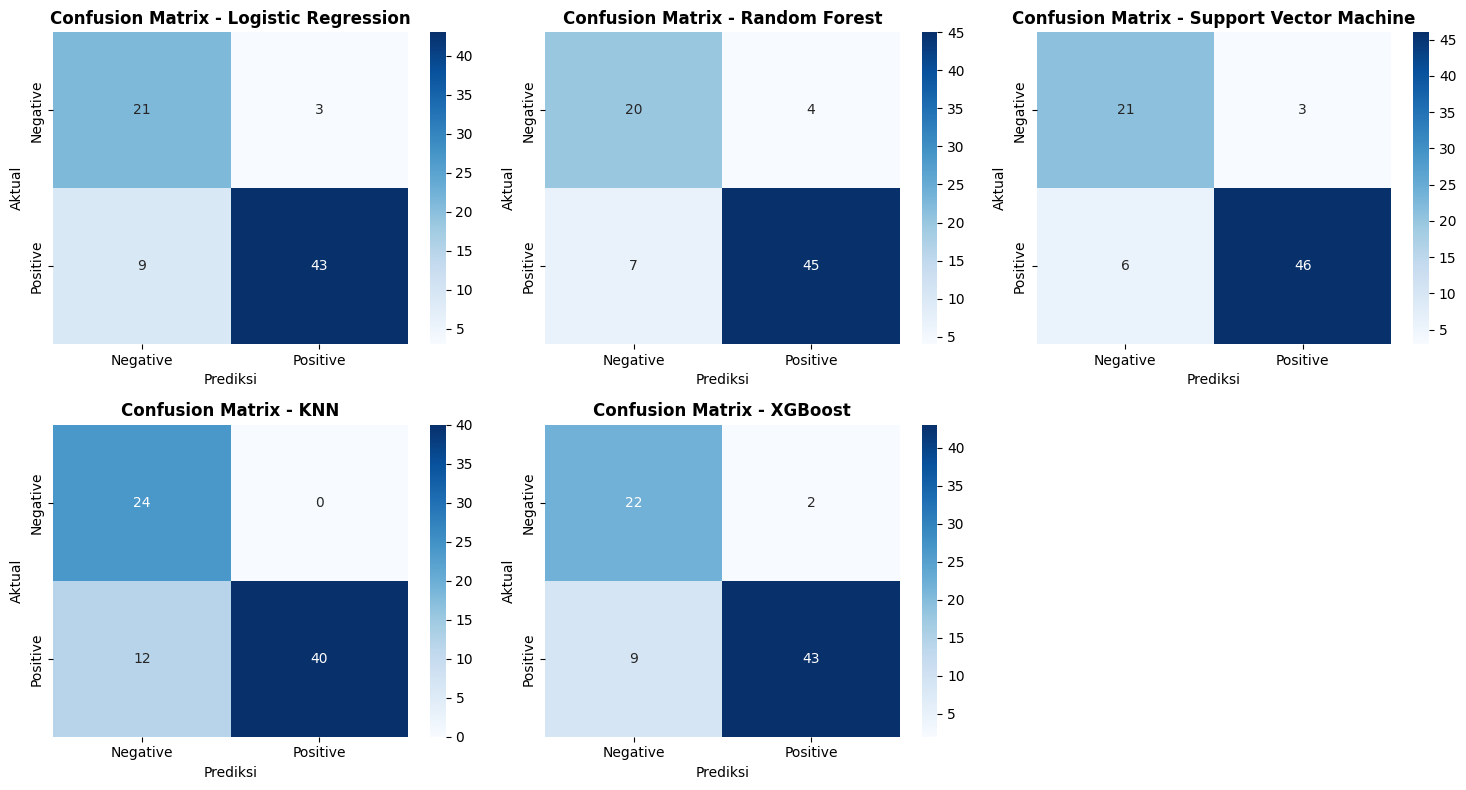

In [53]:
# ==============================================================================
# C. Visualisasi: Confusion Matrix (Seluruh 5 Model)
# ==============================================================================
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, (name, model) in enumerate(final_models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Negative', 'Positive'],
                yticklabels=['Negative', 'Positive'])
    axes[idx].set_title(f'Confusion Matrix - {name}', fontweight='bold')
    axes[idx].set_xlabel('Prediksi')
    axes[idx].set_ylabel('Aktual')

fig.delaxes(axes[5])

plt.tight_layout()
plt.show()

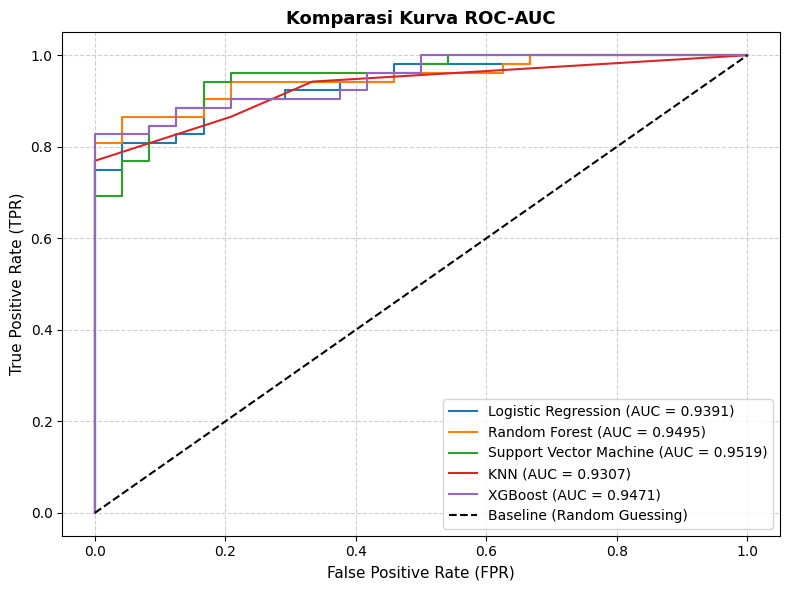

In [54]:
# ==============================================================================
# D. Visualisasi: Kurva ROC-AUC (Seluruh 5 Model)
# ==============================================================================
plt.figure(figsize=(8, 6))

for name, model in final_models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_val = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc_val:.4f})')

plt.plot([0, 1], [0, 1], 'k--', label='Baseline (Random Guessing)')
plt.xlabel('False Positive Rate (FPR)', fontsize=11)
plt.ylabel('True Positive Rate (TPR)', fontsize=11)
plt.title('Komparasi Kurva ROC-AUC', fontsize=13, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()